In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold, cross_validate, RandomizedSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, make_scorer, f1_score,
    precision_score, recall_score, roc_curve
)
from sklearn.preprocessing import StandardScaler
from scipy.sparse import csr_matrix
from scipy.stats import randint, uniform


import warnings
warnings.filterwarnings('ignore')

# Load the feature matrix
#df = pd.read_parquet(r"MODEL_READY_MATRIX.parquet")
#df = pd.read_parquet(r"MODEL_READY_MATRIX_BALANCED.parquet")
df = pd.read_parquet(r"MODEL_READY_MATRIX_BALANCED_NAMED_LABS.parquet")

print(f"Loaded matrix: {df.shape}")
print(f"  Label=1 (AD): {(df['LABEL']==1).sum()}")
print(f"  Label=0 (Control): {(df['LABEL']==0).sum()}")

# Separate features and target
feature_cols = [c for c in df.columns if c not in ['SUBJECT_ID', 'LABEL']]
X = df[feature_cols]
y = df['LABEL']

#hit memory limits so convert to sparse matrix and float32. Shouldn't lose much precision since these are mostly binary features.
X = X.astype(np.float32)
X_sparse = csr_matrix(X.values)


print(f"Features: {X.shape[1]}")

Loaded matrix: (152, 6709)
  Label=1 (AD): 76
  Label=0 (Control): 76
Features: 6707


In [2]:
N_FOLDS = 5
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)

scoring = {
    'accuracy': 'accuracy',
    'f1': make_scorer(f1_score, zero_division=0),
    'precision': make_scorer(precision_score, zero_division=0),
    'recall': make_scorer(recall_score, zero_division=0),
    'roc_auc': 'roc_auc',
}

print(f"Cross-validation: {N_FOLDS}-fold stratified")
print(f"Positive class prevalence: {y.mean():.4f}")

Cross-validation: 5-fold stratified
Positive class prevalence: 0.5000


In [3]:
dt = DecisionTreeClassifier(
    class_weight='balanced',
    max_depth=10,          # Prevent overfitting on sparse features
    min_samples_leaf=20,   # Ensure leaves have enough samples
    random_state=42
)

print("Training Decision Tree with cross-validation...")
dt_cv = cross_validate(
    dt, X_sparse, y,
    cv=skf,
    scoring=scoring,
    return_estimator=True,  # Keep fitted models for feature importance
    n_jobs=-1
)

print("\nDecision Tree Results (mean +/- std across folds):")
for metric in scoring:
    scores = dt_cv[f'test_{metric}']
    print(f"  {metric}: {scores.mean():.4f} +/- {scores.std():.4f}")

# Average feature importances across folds
dt_importances = np.mean(
    [est.feature_importances_ for est in dt_cv['estimator']],
    axis=0
)

dt_importance_df = pd.DataFrame({
    'feature': feature_cols,
    'importance': dt_importances
}).sort_values('importance', ascending=False)

print(f"\nNon-zero importance features: {(dt_importances > 0).sum()}")

Training Decision Tree with cross-validation...

Decision Tree Results (mean +/- std across folds):
  accuracy: 0.6637 +/- 0.0884
  f1: 0.6692 +/- 0.0976
  precision: 0.6576 +/- 0.0883
  recall: 0.6950 +/- 0.1394
  roc_auc: 0.7079 +/- 0.0569

Non-zero importance features: 13


In [4]:
'''
lasso_scores = {m: [] for m in ['f1', 'precision', 'recall', 'roc_auc', 'accuracy']}
lasso_coefs = []
lasso_last_fold = {}  # Store last fold for classification report

print("Training Lasso (L1 Logistic Regression) fold by fold...")

for fold_num, (train_idx, test_idx) in enumerate(skf.split(X_sparse, y)):
    print(f"  Fold {fold_num + 1}/{N_FOLDS}...", end=" ")
    
    X_tr = X_sparse[train_idx]
    X_te = X_sparse[test_idx]
    y_tr = y.iloc[train_idx]
    y_te = y.iloc[test_idx]
    
    scaler = StandardScaler(with_mean=False)
    X_tr_scaled = scaler.fit_transform(X_tr)
    X_te_scaled = scaler.transform(X_te)
    
    del X_tr, X_te
    gc.collect()
    
    lasso = LogisticRegression(
        penalty='l1',
        solver='saga',
        class_weight='balanced',
        max_iter=5000,
        C=1.0,
        random_state=42,
        n_jobs=1
    )
    lasso.fit(X_tr_scaled, y_tr)
    
    y_pred = lasso.predict(X_te_scaled)
    y_prob = lasso.predict_proba(X_te_scaled)[:, 1]
    
    lasso_scores['accuracy'].append((y_pred == y_te).mean())
    lasso_scores['f1'].append(f1_score(y_te, y_pred, zero_division=0))
    lasso_scores['precision'].append(precision_score(y_te, y_pred, zero_division=0))
    lasso_scores['recall'].append(recall_score(y_te, y_pred, zero_division=0))
    lasso_scores['roc_auc'].append(roc_auc_score(y_te, y_prob))
    lasso_coefs.append(np.abs(lasso.coef_[0]))
    
    # Save last fold data for classification report later
    lasso_last_fold = {
        'y_test': y_te,
        'y_pred': y_pred,
        'test_idx': test_idx
    }
    
    print(f"AUC: {lasso_scores['roc_auc'][-1]:.4f}")
    
    del X_tr_scaled, X_te_scaled, lasso, scaler, y_pred, y_prob
    gc.collect()

print("\nLasso Results (mean +/- std across folds):")
for metric in lasso_scores:
    s = np.array(lasso_scores[metric])
    print(f"  {metric}: {s.mean():.4f} +/- {s.std():.4f}")

lasso_coefs_avg = np.mean(lasso_coefs, axis=0)
lasso_importance_df = pd.DataFrame({
    'feature': feature_cols,
    'importance': lasso_coefs_avg
}).sort_values('importance', ascending=False)

print(f"\nNon-zero coefficient features: {(lasso_coefs_avg > 0).sum()}")

del lasso_coefs
gc.collect()
'''

'\nlasso_scores = {m: [] for m in [\'f1\', \'precision\', \'recall\', \'roc_auc\', \'accuracy\']}\nlasso_coefs = []\nlasso_last_fold = {}  # Store last fold for classification report\n\nprint("Training Lasso (L1 Logistic Regression) fold by fold...")\n\nfor fold_num, (train_idx, test_idx) in enumerate(skf.split(X_sparse, y)):\n    print(f"  Fold {fold_num + 1}/{N_FOLDS}...", end=" ")\n    \n    X_tr = X_sparse[train_idx]\n    X_te = X_sparse[test_idx]\n    y_tr = y.iloc[train_idx]\n    y_te = y.iloc[test_idx]\n    \n    scaler = StandardScaler(with_mean=False)\n    X_tr_scaled = scaler.fit_transform(X_tr)\n    X_te_scaled = scaler.transform(X_te)\n    \n    del X_tr, X_te\n    gc.collect()\n    \n    lasso = LogisticRegression(\n        penalty=\'l1\',\n        solver=\'saga\',\n        class_weight=\'balanced\',\n        max_iter=5000,\n        C=1.0,\n        random_state=42,\n        n_jobs=1\n    )\n    lasso.fit(X_tr_scaled, y_tr)\n    \n    y_pred = lasso.predict(X_te_scaled)\n  

In [5]:

# Lasso needs scaled features for proper regularization
scaler = StandardScaler(with_mean=False)  # with_mean=False because X is sparse
X_scaled = scaler.fit_transform(X_sparse)

'''
lasso = LogisticRegression(
    penalty='l1',
    solver='saga',
    class_weight='balanced',
    max_iter=5000,
    C=1.0,               # Regularization strength (lower = more regularization)
    random_state=42,
    n_jobs=1 #changing to 1 to help with memory issues on large datasets
)
'''

lasso = LogisticRegression(
    penalty='l1',
    solver='liblinear',
    class_weight='balanced',
    max_iter=5000,
    C=1.0,               # Regularization strength (lower = more regularization)
    random_state=42,
)

print("Training Lasso (L1 Logistic Regression) with cross-validation...")
lasso_cv = cross_validate(
    lasso, X_scaled, y,
    cv=skf,
    scoring=scoring,
    return_estimator=True,
    n_jobs=1 # changing to 1 to help with memory issues on large datasets
)

print("\nLasso Results (mean +/- std across folds):")
for metric in scoring:
    scores = lasso_cv[f'test_{metric}']
    print(f"  {metric}: {scores.mean():.4f} +/- {scores.std():.4f}")

# Average absolute coefficients across folds
lasso_coefs = np.mean(
    [np.abs(est.coef_[0]) for est in lasso_cv['estimator']],
    axis=0
)

lasso_importance_df = pd.DataFrame({
    'feature': feature_cols,
    'importance': lasso_coefs
}).sort_values('importance', ascending=False)

print(f"\nNon-zero coefficient features: {(lasso_coefs > 0).sum()}")


Training Lasso (L1 Logistic Regression) with cross-validation...

Lasso Results (mean +/- std across folds):
  accuracy: 0.5662 +/- 0.0664
  f1: 0.4748 +/- 0.1518
  precision: 0.5727 +/- 0.1313
  recall: 0.4208 +/- 0.1708
  roc_auc: 0.6636 +/- 0.0991

Non-zero coefficient features: 325


Accuracy = correct predictions/total predictions

precision = PPV

recall = sensitivity (true pos / total pos)

In [6]:
''' Add Random Forest'''
# setup random forest classifier with hyperparameters that are reasonable for this dataset #this is first pass
# class_weight='balanced_subsample' reweights per bootstrap sample

rf_base = RandomForestClassifier(
    n_estimators=500,
    max_depth=10,
    min_samples_leaf=5,
    min_samples_split=10,
    max_features='sqrt',        # decorrelate trees
    class_weight='balanced_subsample',
    random_state=42,
    n_jobs=-1,
)

print("\n[1/3] Training Random Forest (baseline) with cross-validation...")
rf_cv = cross_validate(
    rf_base, X_sparse, y,
    cv=skf,
    scoring=scoring,
    return_estimator=True,
    n_jobs=1  # outer loop sequential to avoid mem issues w/ nested parallelism
)

print("\nRandom Forest Baseline Results (mean ± std across folds):")
for metric in scoring:
    scores = rf_cv[f'test_{metric}']
    print(f"  {metric}: {scores.mean():.4f} ± {scores.std():.4f}")


# now do hyperparameter tuning with RandomizedSearchCV
print("\n[2/3] Running RandomizedSearchCV for hyperparameter tuning...")

param_dist = {
    'n_estimators': randint(300, 2000),
    'max_depth': randint(5, 25),
    'min_samples_leaf': randint(2, 20),
    'min_samples_split': randint(2, 20),
    'max_features': ['sqrt', 'log2', 0.1, 0.2, 0.3],
    'class_weight': ['balanced', 'balanced_subsample'],
}

optimzation_metric = 'recall'  # prioritize recall so we never miss a patient

rf_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_distributions=param_dist,
    n_iter=30,
    scoring=optimzation_metric,  # prioritize recall so we never miss a patient
    cv=skf,
    random_state=42,
    n_jobs=1,
    verbose=1,
)
rf_search.fit(X_sparse, y)

print(f"\nBest {optimzation_metric} from search: {rf_search.best_score_:.4f}")
print(f"Best params: {rf_search.best_params_}")


# cross val
print("\n[3/3] Evaluating tuned Random Forest with cross-validation...")
rf_tuned = rf_search.best_estimator_

rf_tuned_cv = cross_validate(
    rf_tuned, X_sparse, y,
    cv=skf,
    scoring=scoring,
    return_estimator=True,
    n_jobs=1
)

print("\nTuned Random Forest Results (mean ± std across folds):")
for metric in scoring:
    scores = rf_tuned_cv[f'test_{metric}']
    print(f"  {metric}: {scores.mean():.4f} ± {scores.std():.4f}")



# Average feature importances across folds
rf_tuned_importances = np.mean(
    [est.feature_importances_ for est in rf_tuned_cv['estimator']],
    axis=0
)
rf_tuned_importance_df = pd.DataFrame({
    'feature': feature_cols,
    'importance': rf_tuned_importances
}).sort_values('importance', ascending=False)


[1/3] Training Random Forest (baseline) with cross-validation...

Random Forest Baseline Results (mean ± std across folds):
  accuracy: 0.6847 ± 0.0957
  f1: 0.6990 ± 0.1078
  precision: 0.6715 ± 0.1018
  recall: 0.7500 ± 0.1599
  roc_auc: 0.7525 ± 0.0996

[2/3] Running RandomizedSearchCV for hyperparameter tuning...
Fitting 5 folds for each of 30 candidates, totalling 150 fits

Best recall from search: 0.8150
Best params: {'class_weight': 'balanced', 'max_depth': 5, 'max_features': 0.3, 'min_samples_leaf': 15, 'min_samples_split': 8, 'n_estimators': 1094}

[3/3] Evaluating tuned Random Forest with cross-validation...

Tuned Random Forest Results (mean ± std across folds):
  accuracy: 0.7105 ± 0.0381
  f1: 0.7318 ± 0.0616
  precision: 0.6843 ± 0.0533
  recall: 0.8150 ± 0.1550
  roc_auc: 0.7699 ± 0.0791


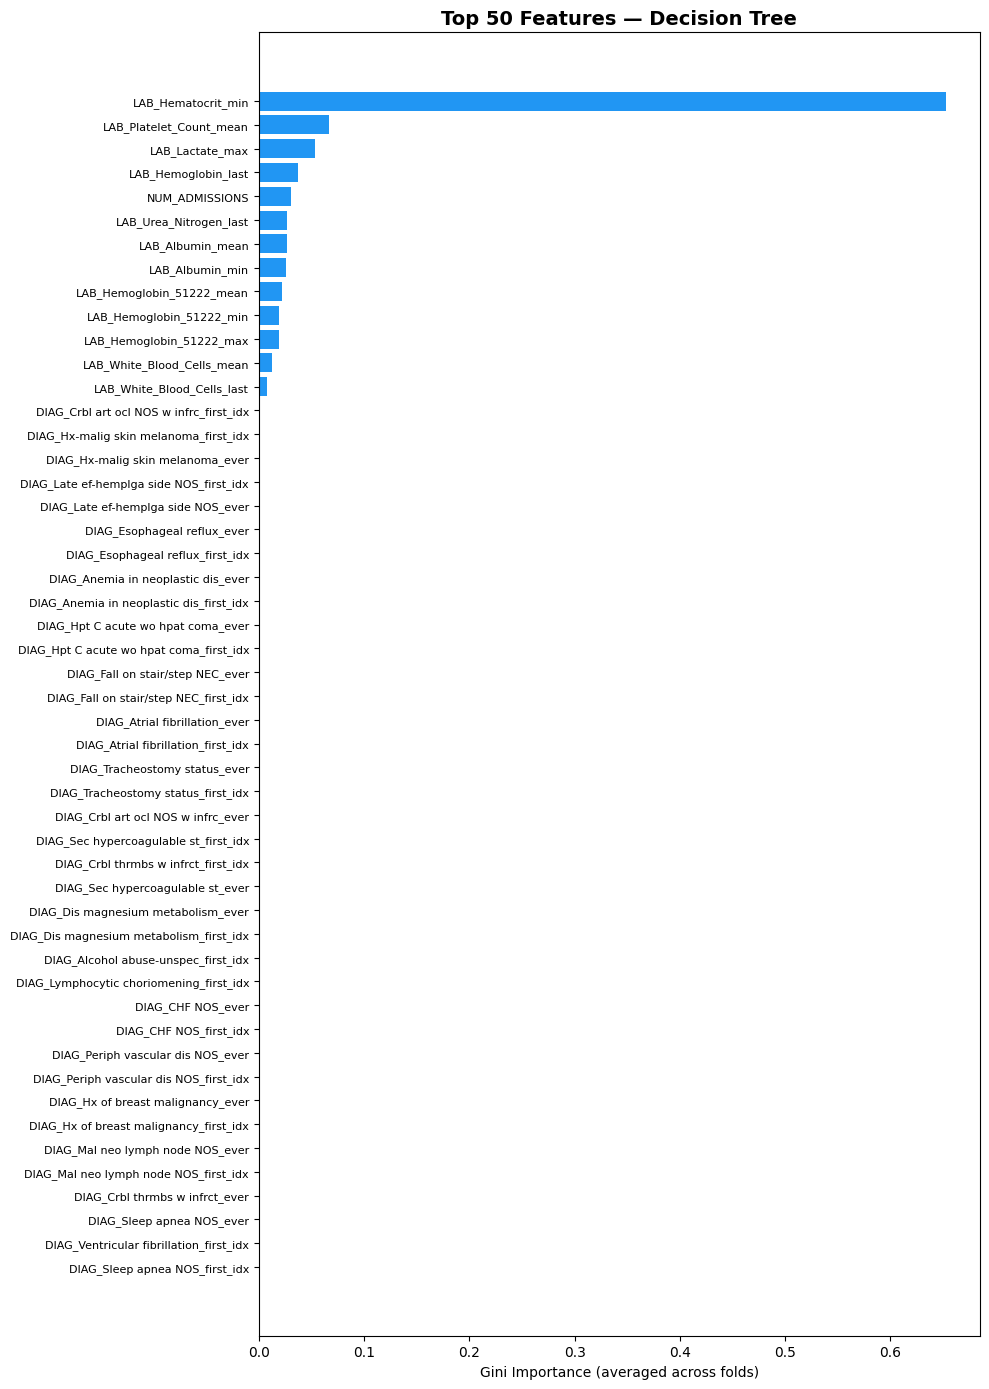

Saved: DT_Top50_Features.png


In [7]:
TOP_N = 50

dt_top = dt_importance_df.head(TOP_N).sort_values('importance', ascending=True)

fig, ax = plt.subplots(figsize=(10, 14))
ax.barh(dt_top['feature'], dt_top['importance'], color='#2196F3')
ax.set_xlabel('Gini Importance (averaged across folds)')
ax.set_title(f'Top {TOP_N} Features — Decision Tree', fontsize=14, fontweight='bold')
ax.tick_params(axis='y', labelsize=8)
plt.tight_layout()
plt.savefig(r"DT_Top50_Features.png", dpi=150, bbox_inches='tight')
plt.show()

print("Saved: DT_Top50_Features.png")

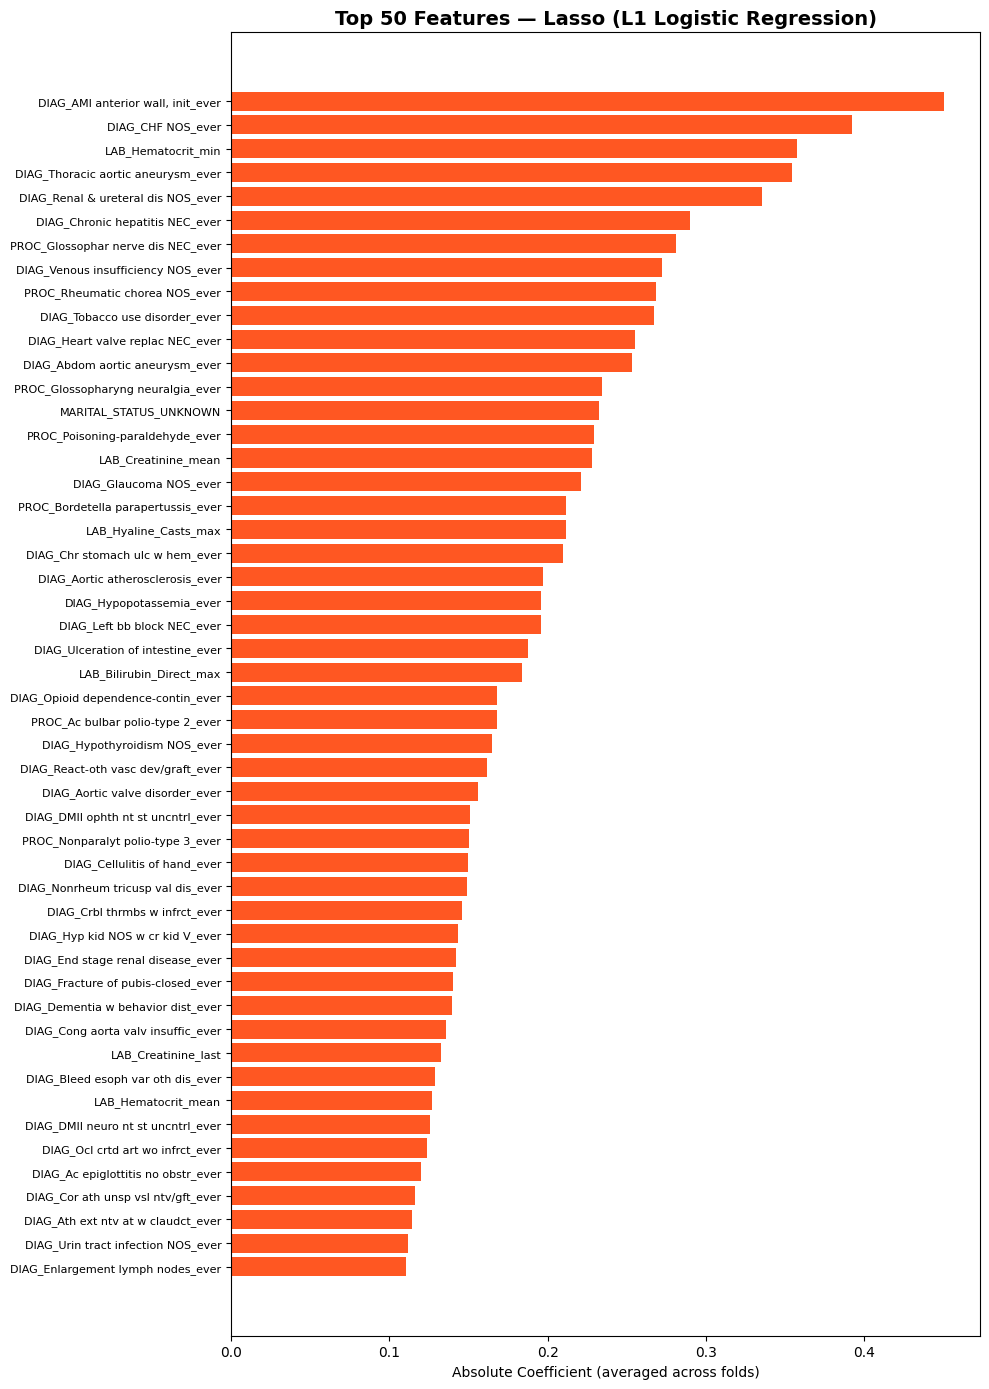

Saved: Lasso_Top50_Features.png


In [8]:
lasso_top = lasso_importance_df.head(TOP_N).sort_values('importance', ascending=True)

fig, ax = plt.subplots(figsize=(10, 14))
ax.barh(lasso_top['feature'], lasso_top['importance'], color='#FF5722')
ax.set_xlabel('Absolute Coefficient (averaged across folds)')
ax.set_title(f'Top {TOP_N} Features — Lasso (L1 Logistic Regression)', fontsize=14, fontweight='bold')
ax.tick_params(axis='y', labelsize=8)
plt.tight_layout()
plt.savefig(r"Lasso_Top50_Features.png", dpi=150, bbox_inches='tight')
plt.show()

print("Saved: Lasso_Top50_Features.png")

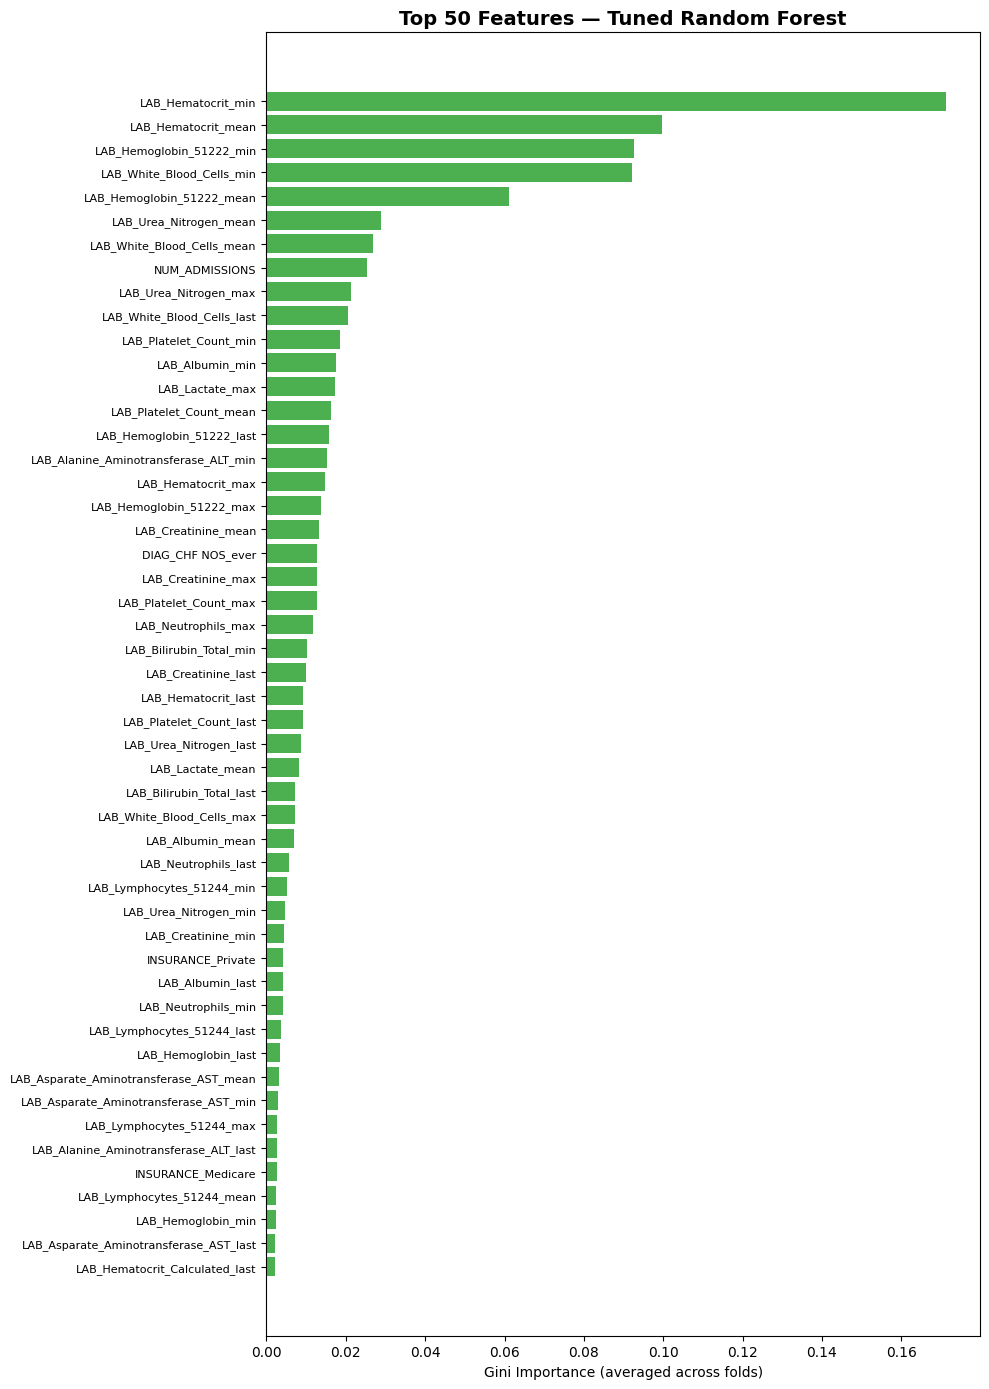

Saved: RF_Tuned_Top50_Features.png


In [9]:
# now display for tuned random forest
#Feature importance bar chart
rf_top = rf_tuned_importance_df.head(TOP_N).sort_values('importance', ascending=True)

fig, ax = plt.subplots(figsize=(10, 14))
ax.barh(rf_top['feature'], rf_top['importance'], color='#4CAF50')
ax.set_xlabel('Gini Importance (averaged across folds)')
ax.set_title(f'Top {TOP_N} Features — Tuned Random Forest', fontsize=14, fontweight='bold')
ax.tick_params(axis='y', labelsize=8)
plt.tight_layout()
plt.savefig(r"RF_Tuned_Top50_Features.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: RF_Tuned_Top50_Features.png")

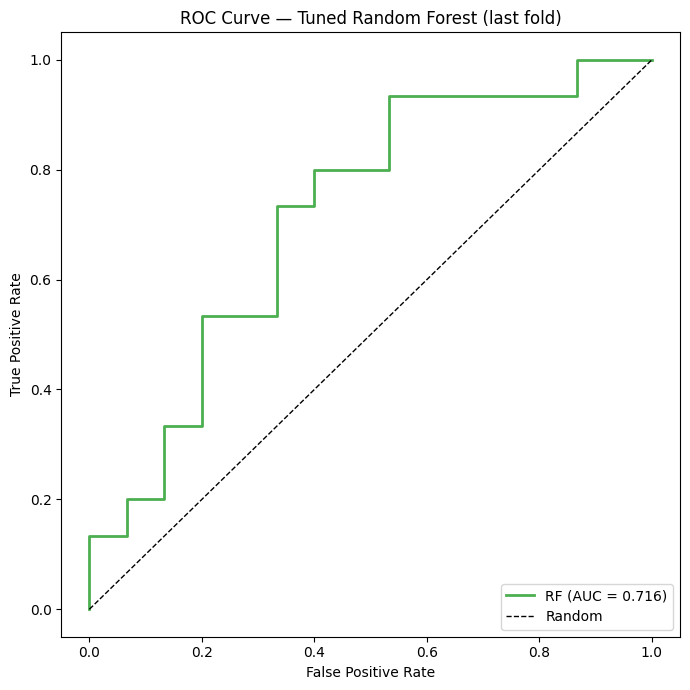

Saved: RF_Tuned_ROC.png


In [10]:
# Random Forest ROC curve
fold_indices = list(skf.split(X_sparse, y))
_, test_idx = fold_indices[-1]
X_test_fold = X_sparse[test_idx]
y_test_fold = y.iloc[test_idx]

rf_last = rf_tuned_cv['estimator'][-1]
y_prob = rf_last.predict_proba(X_test_fold)[:, 1]
fpr, tpr, _ = roc_curve(y_test_fold, y_prob)
auc_val = roc_auc_score(y_test_fold, y_prob)

fig, ax = plt.subplots(figsize=(7, 7))
ax.plot(fpr, tpr, color='#4CAF50', lw=2, label=f'RF (AUC = {auc_val:.3f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve — Tuned Random Forest (last fold)')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig(r"RF_Tuned_ROC.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: RF_Tuned_ROC.png")

type(shap_values) : <class 'numpy.ndarray'>
ndarray shape: (30, 6707, 2)
final sv_to_plot.shape : (30, 6707)
X_test_dense.shape     : (30, 6707)


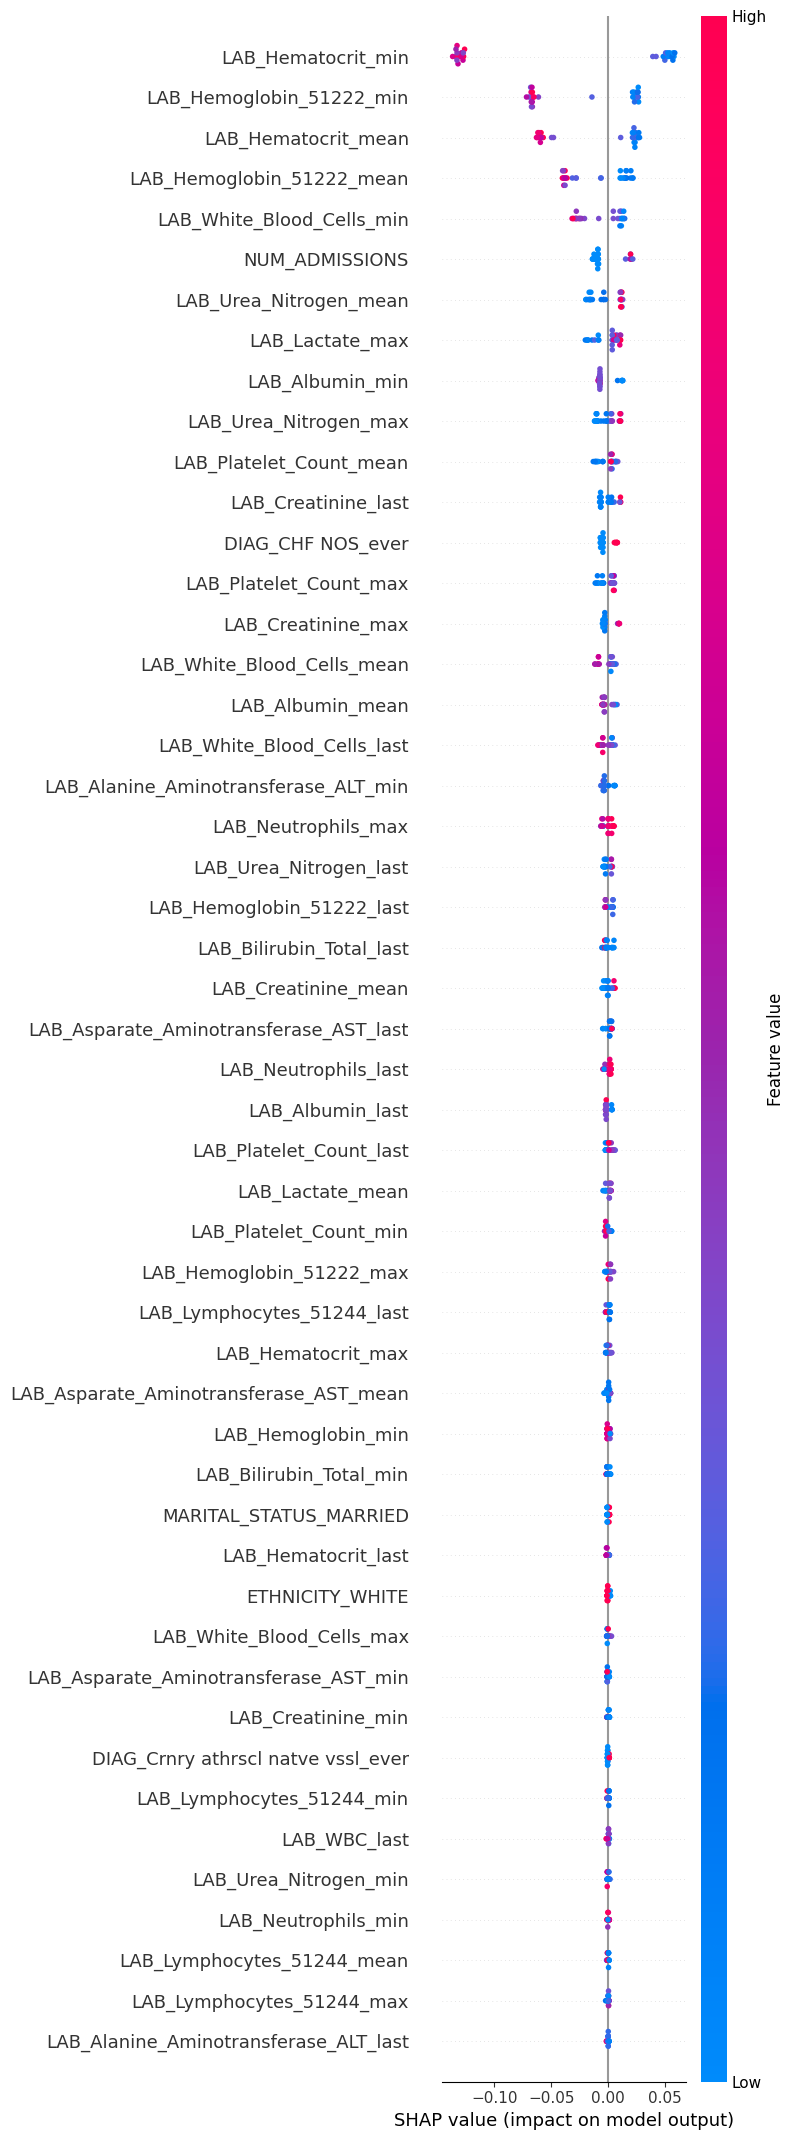

Saved: RF_Tuned_SHAP.png


In [11]:
import shap

# --- rebuild last fold cleanly ---
fold_indices = list(skf.split(X_sparse, y))
_, test_idx = fold_indices[-1]

X_test_dense = X_sparse[test_idx].toarray().astype(np.float64)
y_test_fold  = y.iloc[test_idx]

rf_last = rf_tuned_cv['estimator'][-1]

# --- SHAP ---
rf_explainer = shap.TreeExplainer(
    rf_last,
    feature_perturbation="interventional"
)
shap_values = rf_explainer.shap_values(X_test_dense, check_additivity=False)

print("type(shap_values) :", type(shap_values))

if isinstance(shap_values, list):
    print("shapes:", [sv.shape for sv in shap_values])
    sv_to_plot = shap_values[1]                    # list[1] = class 1

elif isinstance(shap_values, np.ndarray):
    print("ndarray shape:", shap_values.shape)
    n_feat = X_test_dense.shape[1]

    if shap_values.ndim == 2:
        sv_to_plot = shap_values                   # already 2D

    elif shap_values.ndim == 3:
        # work out which axis is classes (size 2) vs features (size n_feat)
        if shap_values.shape[2] == n_feat:         # (samples, classes, features)
            sv_to_plot = shap_values[:, 1, :]
        elif shap_values.shape[1] == n_feat:       # (samples, features, classes)
            sv_to_plot = shap_values[:, :, 1]
        elif shap_values.shape[0] == n_feat:       # (features, samples, classes) — unlikely
            sv_to_plot = shap_values[:, :, 1].T
        else:
            raise ValueError(f"can't map 3D shap shape {shap_values.shape} to features={n_feat}")
    else:
        raise ValueError(f"unexpected shap ndim: {shap_values.ndim}")

else:
    raise TypeError(f"unexpected shap_values type: {type(shap_values)}")

# trim bias column if present
if sv_to_plot.shape[1] == X_test_dense.shape[1] + 1:
    print("trimming bias column")
    sv_to_plot = sv_to_plot[:, :-1]

print("final sv_to_plot.shape :", sv_to_plot.shape)
print("X_test_dense.shape     :", X_test_dense.shape)
assert sv_to_plot.shape == X_test_dense.shape, "shapes still mismatched!"

shap.summary_plot(
    sv_to_plot,
    X_test_dense,
    feature_names=feature_cols,
    max_display=TOP_N,
    show=False,
    plot_type="dot"
)
plt.tight_layout()
plt.savefig(r"RF_Tuned_SHAP.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: RF_Tuned_SHAP.png")

In [12]:
# Random Forest classification report and confusion matrix for last fold
y_pred = rf_last.predict(X_test_fold)
print("\n" + "=" * 60)
print("Tuned Random Forest — Classification Report (last fold)")
print("=" * 60)
print(classification_report(y_test_fold, y_pred, target_names=['Control', 'Disease']))

# Confusion matrix (last fold)
cm = confusion_matrix(y_test_fold, y_pred)
print("Confusion Matrix:")
print(cm)


Tuned Random Forest — Classification Report (last fold)
              precision    recall  f1-score   support

     Control       0.63      0.80      0.71        15
     Disease       0.73      0.53      0.62        15

    accuracy                           0.67        30
   macro avg       0.68      0.67      0.66        30
weighted avg       0.68      0.67      0.66        30

Confusion Matrix:
[[12  3]
 [ 7  8]]


In [13]:
# Show overlap between the Decision Tree and Lasso top 50
dt_top50_set = set(dt_importance_df.head(TOP_N)['feature'])
lasso_top50_set = set(lasso_importance_df.head(TOP_N)['feature'])
overlap = dt_top50_set & lasso_top50_set

print(f"\nTop {TOP_N} overlap between Decision Tree and Lasso:")
print(f"  Features in both: {len(overlap)}")
print(f"  Only in Decision Tree: {len(dt_top50_set - lasso_top50_set)}")
print(f"  Only in Lasso: {len(lasso_top50_set - dt_top50_set)}")
print(f"\nShared features:")
for f in sorted(overlap):
    print(f"  {f}")

# Export full importance rankings
dt_importance_df.to_csv(
    r"DT_Feature_Importances.csv", index=False
)
lasso_importance_df.to_csv(
    r"Lasso_Feature_Importances.csv", index=False
)

print("\nSaved full importance rankings as CSV.")


Top 50 overlap between Decision Tree and Lasso:
  Features in both: 3
  Only in Decision Tree: 47
  Only in Lasso: 47

Shared features:
  DIAG_CHF NOS_ever
  DIAG_Crbl thrmbs w infrct_ever
  LAB_Hematocrit_min

Saved full importance rankings as CSV.


In [14]:
# Show overlap between random forest and lasso top 50
rf_top50_set = set(rf_tuned_importance_df.head(TOP_N)['feature'])
rf_lasso_overlap = rf_top50_set & lasso_top50_set

print(f"\nTop {TOP_N} overlap between Tuned Random Forest and Lasso:")
print(f"  Features in both: {len(rf_lasso_overlap)}")
print(f"  Only in Tuned Random Forest: {len(rf_top50_set - lasso_top50_set)}")
print(f"  Only in Lasso: {len(lasso_top50_set - rf_top50_set)}")
print(f"\nShared features:")
for f in sorted(rf_lasso_overlap):
    print(f"  {f}")


Top 50 overlap between Tuned Random Forest and Lasso:
  Features in both: 5
  Only in Tuned Random Forest: 45
  Only in Lasso: 45

Shared features:
  DIAG_CHF NOS_ever
  LAB_Creatinine_last
  LAB_Creatinine_mean
  LAB_Hematocrit_mean
  LAB_Hematocrit_min


In [15]:
# Use the last fold's estimator for a detailed report
dt_last = dt_cv['estimator'][-1]
lasso_last = lasso_cv['estimator'][-1]

# Get the last fold's test indices
fold_indices = list(skf.split(X, y))
_, test_idx = fold_indices[-1]

X_test_fold = X_sparse[test_idx]
X_test_fold_scaled = X_scaled[test_idx]
y_test_fold = y.iloc[test_idx]

print("=" * 60)
print("Decision Tree — Classification Report (last fold)")
print("=" * 60)
dt_pred = dt_last.predict(X_test_fold)
print(classification_report(y_test_fold, dt_pred, target_names=['Control', 'AD']))

print("=" * 60)
print("Lasso — Classification Report (last fold)")
print("=" * 60)
lasso_pred = lasso_last.predict(X_test_fold_scaled)
print(classification_report(y_test_fold, lasso_pred, target_names=['Control', 'AD']))

Decision Tree — Classification Report (last fold)
              precision    recall  f1-score   support

     Control       0.59      0.67      0.62        15
          AD       0.62      0.53      0.57        15

    accuracy                           0.60        30
   macro avg       0.60      0.60      0.60        30
weighted avg       0.60      0.60      0.60        30

Lasso — Classification Report (last fold)
              precision    recall  f1-score   support

     Control       0.57      0.80      0.67        15
          AD       0.67      0.40      0.50        15

    accuracy                           0.60        30
   macro avg       0.62      0.60      0.58        30
weighted avg       0.62      0.60      0.58        30



In [16]:
'''
# Use the last fold's estimator for a detailed report
dt_last = dt_cv['estimator'][-1]
lasso_last = lasso_cv['estimator'][-1]

# Get the last fold's test indices
fold_indices = list(skf.split(X_sparse, y))
_, test_idx = fold_indices[-1]

X_test_fold = X.iloc[test_idx]
X_test_fold_scaled = X_scaled[test_idx]
y_test_fold = y.iloc[test_idx]

print("=" * 60)
print("Decision Tree — Classification Report (last fold)")
print("=" * 60)
dt_pred = dt_last.predict(X_test_fold)
print(classification_report(y_test_fold, dt_pred, target_names=['Control', 'AD']))

print("=" * 60)
print("Lasso — Classification Report (last fold)")
print("=" * 60)
lasso_pred = lasso_last.predict(X_test_fold_scaled)
print(classification_report(y_test_fold, lasso_pred, target_names=['Control', 'AD']))
'''

'\n# Use the last fold\'s estimator for a detailed report\ndt_last = dt_cv[\'estimator\'][-1]\nlasso_last = lasso_cv[\'estimator\'][-1]\n\n# Get the last fold\'s test indices\nfold_indices = list(skf.split(X_sparse, y))\n_, test_idx = fold_indices[-1]\n\nX_test_fold = X.iloc[test_idx]\nX_test_fold_scaled = X_scaled[test_idx]\ny_test_fold = y.iloc[test_idx]\n\nprint("=" * 60)\nprint("Decision Tree — Classification Report (last fold)")\nprint("=" * 60)\ndt_pred = dt_last.predict(X_test_fold)\nprint(classification_report(y_test_fold, dt_pred, target_names=[\'Control\', \'AD\']))\n\nprint("=" * 60)\nprint("Lasso — Classification Report (last fold)")\nprint("=" * 60)\nlasso_pred = lasso_last.predict(X_test_fold_scaled)\nprint(classification_report(y_test_fold, lasso_pred, target_names=[\'Control\', \'AD\']))\n'